# Gráficos de Perfiles Verticales (PT y Razón de Mezcla)
Este notebook carga los archivos `.txt` extraídos de las simulaciones y genera:
1. Gráficos de Temperatura vs Presión (P-T)
2. Gráficos de Mix Ratios vs Presión para especies químicas importantes


In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ruta a la carpeta que contiene los archivos
data_dir = '../profiles'

def load_pt(filename):
    path = os.path.join(data_dir, filename)
    if os.path.exists(path):
        return pd.read_csv(path, sep=r'\s+')
    return None

def load_mix(filename):
    path = os.path.join(data_dir, filename)
    if os.path.exists(path):
        return pd.read_csv(path, sep=r'\s+')
    return None


## 1. Perfiles P-T

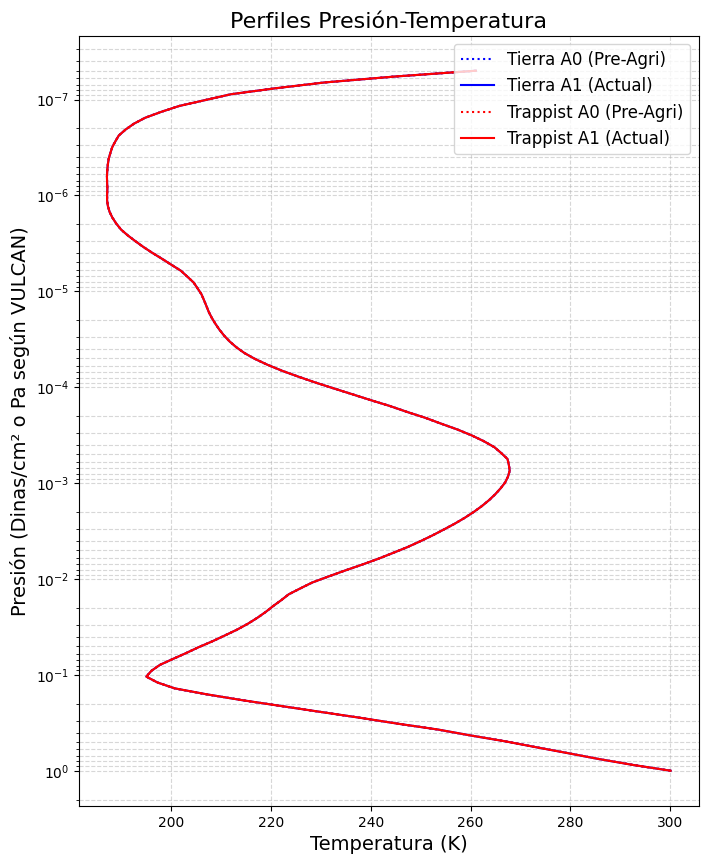

In [7]:
plt.figure(figsize=(8, 10))

# Selecciona los escenarios que desees comparar
scenarios_pt = [
    ('Earth_A0_PreAgri', 'Tierra A0 (Pre-Agri)', 'blue', ':'),
    ('Earth_A1_Current', 'Tierra A1 (Actual)', 'blue', '-'),
    ('Trappist_A0_PreAgri', 'Trappist A0 (Pre-Agri)', 'red', ':'),
    ('Trappist_A1_Current', 'Trappist A1 (Actual)', 'red', '-')
]

for base_name, label, color, ls in scenarios_pt:
    pt_data = load_pt(f"{base_name}_PT.txt")
    if pt_data is not None:
        P = pt_data['P']
        T = pt_data['T']
        plt.plot(T, P, label=label, color=color, linestyle=ls)

plt.yscale('log')
plt.gca().invert_yaxis() # Invertir el eje para que la presión mayor esté abajo (superficie)
plt.xlabel('Temperatura (K)', fontsize=14)
plt.ylabel('Presión (Dinas/cm² o Pa según VULCAN)', fontsize=14)
plt.title('Perfiles Presión-Temperatura', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.show()

## 2. Mixing Ratios vs Presión

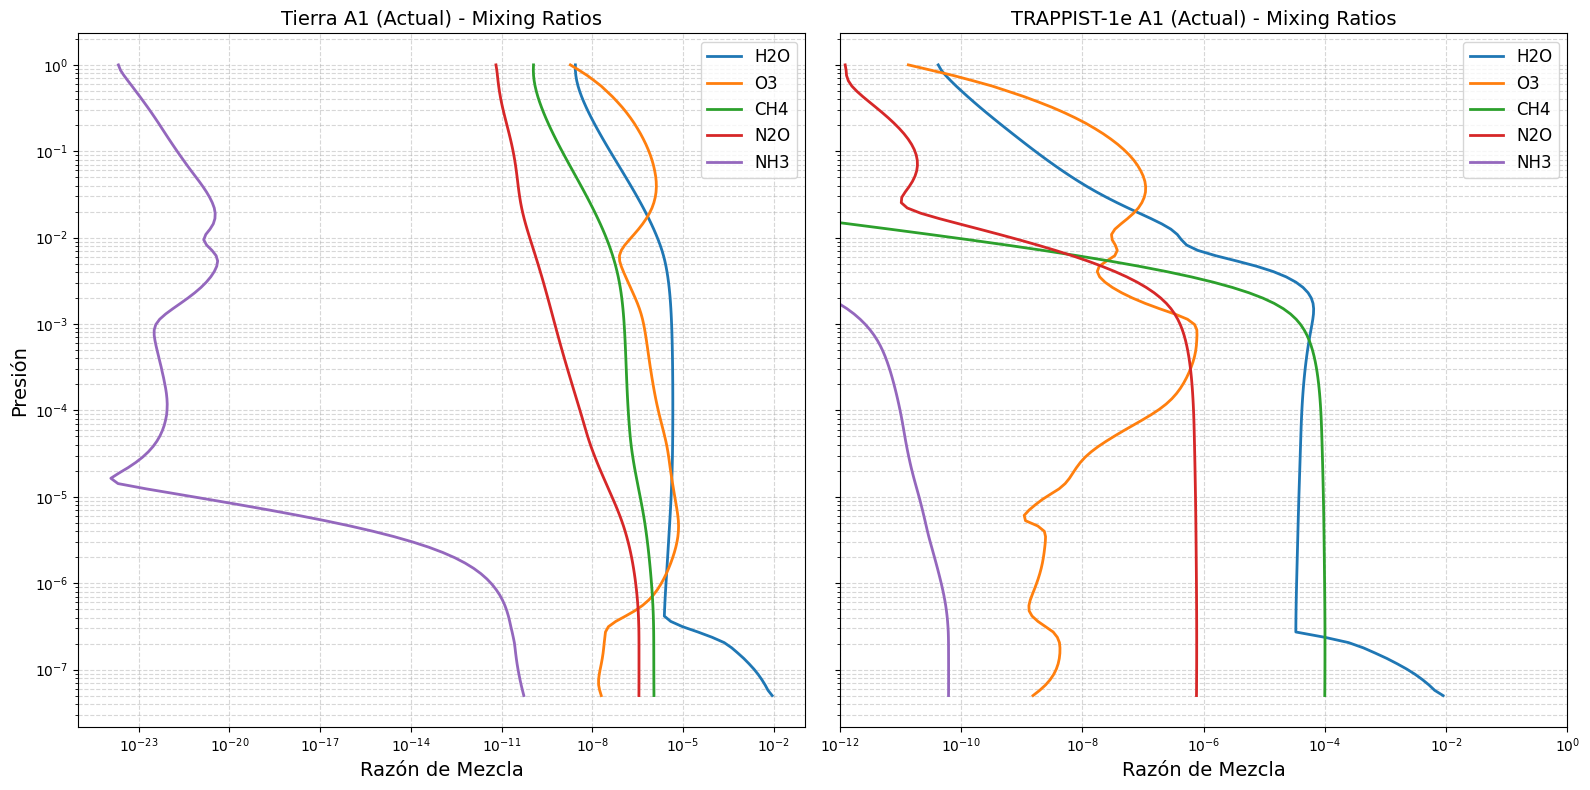

In [10]:
# Moléculas a destacar
molecules = ['H2O', 'O3', 'CH4', 'N2O', 'NH3']

fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Tierra A1
mix_earth = load_mix('Earth_A1_Current_chem.txt')
if mix_earth is not None:
    P = mix_earth['PRESS']
    for mol in molecules:
        if mol in mix_earth.columns:
            axs[0].plot(mix_earth[mol], P[::-1], label=mol, lw=2)
            
    axs[0].set_yscale('log')
    axs[0].invert_yaxis()
    axs[0].set_xscale('log')
    axs[0].set_title('Tierra A1 (Actual) - Mixing Ratios', fontsize=14)
    axs[0].set_xlabel('Razón de Mezcla', fontsize=14)
    axs[0].set_ylabel('Presión', fontsize=14)
    axs[0].legend(fontsize=12)
    axs[0].grid(True, which='both', ls='--', alpha=0.5)

# Trappist A1
mix_trappist = load_mix('Trappist_A1_Current_chem.txt')
if mix_trappist is not None:
    P = mix_trappist['PRESS']
    for mol in molecules:
        if mol in mix_trappist.columns:
            axs[1].plot(mix_trappist[mol], P[::-1], label=mol, lw=2)
            
    axs[1].set_yscale('log')
    axs[1].invert_yaxis()
    axs[1].set_xscale('log')
    axs[1].set_xlim(1e-12, 1) # Normalizar el eje para una mejor comparativa visual si se requiere
    axs[1].set_title('TRAPPIST-1e A1 (Actual) - Mixing Ratios', fontsize=14)
    axs[1].set_xlabel('Razón de Mezcla', fontsize=14)
    axs[1].legend(fontsize=12)
    axs[1].grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()